In [3]:
import json
import os
from collections import defaultdict, Counter

ANNOTATION_PATH = "B:/CV Project/lvis_16k_dataset/annotations.json"
IMAGE_DIR = "B:/CV Project/lvis_16k_dataset/images"

with open(ANNOTATION_PATH) as f:
    data = json.load(f)

images = data['images']
annotations = data['annotations']
categories = data['categories']

print("Images:", len(images))
print("Annotations:", len(annotations))
print("Categories:", len(categories))

Images: 15744
Annotations: 211677
Categories: 1203


In [4]:
# Check unique IDs
image_ids = set(img['id'] for img in images)
ann_image_ids = set(ann['image_id'] for ann in annotations)

print("Unique image IDs:", len(image_ids))
print("Annotation image IDs:", len(ann_image_ids))

# Missing annotations
print("Images without annotations:", len(image_ids - ann_image_ids))

# Missing images
print("Annotations without images:", len(ann_image_ids - image_ids))

Unique image IDs: 15744
Annotation image IDs: 15643
Images without annotations: 101
Annotations without images: 0


In [5]:
cat_count = Counter()

for ann in annotations:
    cat_count[ann['category_id']] += 1

print("Top 10 most frequent categories:")
print(cat_count.most_common(10))

Top 10 most frequent categories:
[(45, 7877), (127, 5572), (12, 3416), (217, 3280), (99, 2357), (387, 2322), (793, 2258), (232, 2252), (154, 2225), (735, 2006)]


In [6]:
cat_id_to_name = {cat['id']: cat['name'] for cat in categories}

for cat_id, count in cat_count.most_common(10):
    print(cat_id_to_name[cat_id], ":", count)

banana : 7877
book : 5572
apple : 3416
carrot : 3280
bird : 2357
doughnut : 2322
person : 2258
chair : 2252
broccoli : 2225
orange_(fruit) : 2006


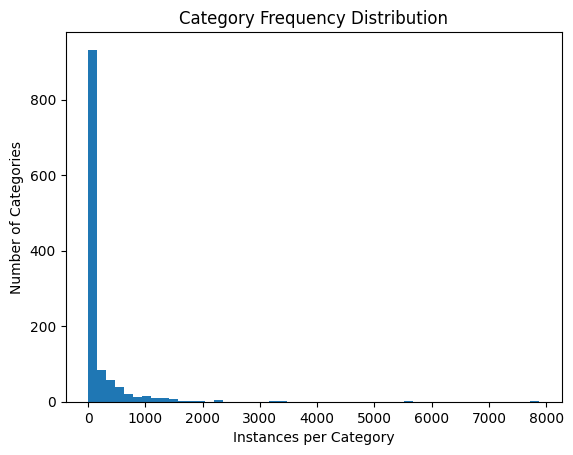

In [7]:
import matplotlib.pyplot as plt

counts = list(cat_count.values())

plt.hist(counts, bins=50)
plt.title("Category Frequency Distribution")
plt.xlabel("Instances per Category")
plt.ylabel("Number of Categories")
plt.show()

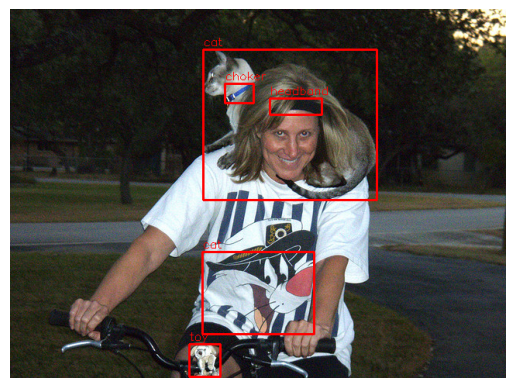

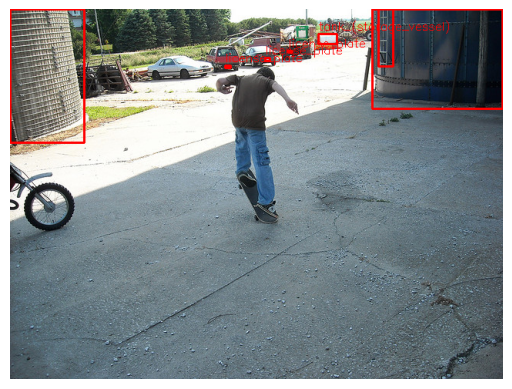

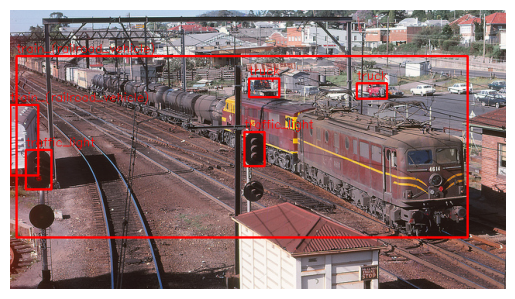

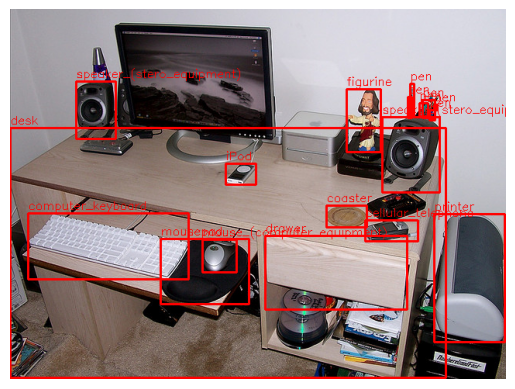

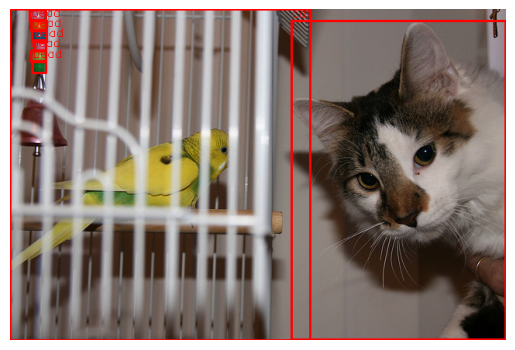

In [10]:
import cv2
import random

# map image_id → annotations
ann_map = defaultdict(list)
for ann in annotations:
    ann_map[ann['image_id']].append(ann)

def show_sample():
    img = random.choice(images)
    img_path = os.path.join(IMAGE_DIR, img['file_name'])

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for ann in ann_map[img['id']]:
        x, y, w, h = ann['bbox']
        x, y, w, h = int(x), int(y), int(w), int(h)

        cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)

        cat_name = cat_id_to_name[ann['category_id']]
        cv2.putText(image, cat_name, (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

    plt.imshow(image)
    plt.axis('off')
    plt.show()

# show 5 samples
for _ in range(5):
    show_sample()

Avg width: 576.0139100609756
Avg height: 487.2797891260163


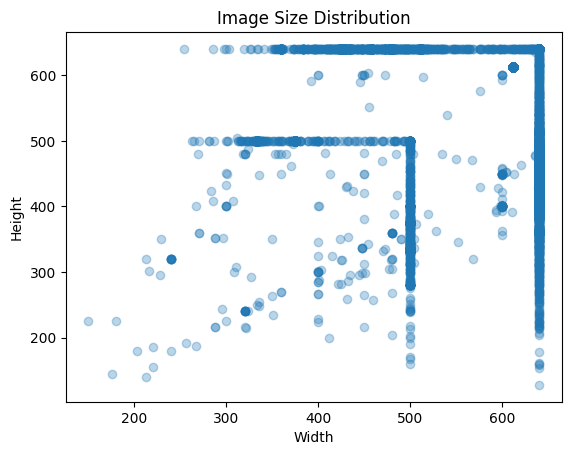

In [11]:
widths = [img['width'] for img in images]
heights = [img['height'] for img in images]

print("Avg width:", sum(widths)/len(widths))
print("Avg height:", sum(heights)/len(heights))

plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

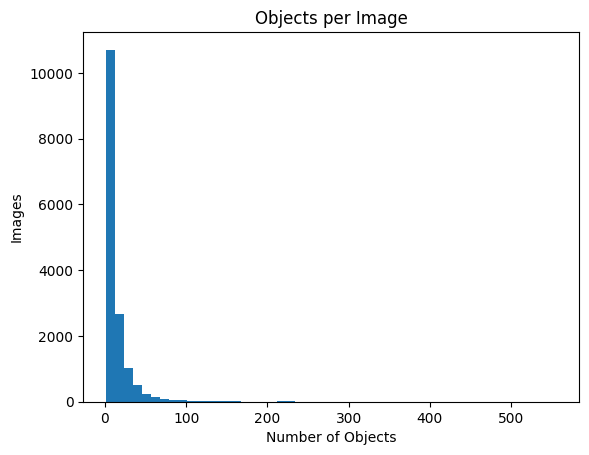

Max objects in an image: 556
Average objects per image: 13.531739436169532


In [12]:
obj_per_image = Counter()

for ann in annotations:
    obj_per_image[ann['image_id']] += 1

values = list(obj_per_image.values())

plt.hist(values, bins=50)
plt.title("Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Images")
plt.show()

print("Max objects in an image:", max(values))
print("Average objects per image:", sum(values)/len(values))

# Checking number of images per categories

In [15]:
from collections import defaultdict

cat_to_images = defaultdict(set)

for ann in annotations:
    cat_id = ann['category_id']
    img_id = ann['image_id']
    cat_to_images[cat_id].add(img_id)

In [16]:
cat_image_count = {
    cat_id: len(img_ids)
    for cat_id, img_ids in cat_to_images.items()
}

In [18]:
cat_id_to_name = {cat['id']: cat['name'] for cat in categories}

In [19]:
cat_id_to_name

{1: 'aerosol_can',
 2: 'air_conditioner',
 3: 'airplane',
 4: 'alarm_clock',
 5: 'alcohol',
 6: 'alligator',
 7: 'almond',
 8: 'ambulance',
 9: 'amplifier',
 10: 'anklet',
 11: 'antenna',
 12: 'apple',
 13: 'applesauce',
 14: 'apricot',
 15: 'apron',
 16: 'aquarium',
 17: 'arctic_(type_of_shoe)',
 18: 'armband',
 19: 'armchair',
 20: 'armoire',
 21: 'armor',
 22: 'artichoke',
 23: 'trash_can',
 24: 'ashtray',
 25: 'asparagus',
 26: 'atomizer',
 27: 'avocado',
 28: 'award',
 29: 'awning',
 30: 'ax',
 31: 'baboon',
 32: 'baby_buggy',
 33: 'basketball_backboard',
 34: 'backpack',
 35: 'handbag',
 36: 'suitcase',
 37: 'bagel',
 38: 'bagpipe',
 39: 'baguet',
 40: 'bait',
 41: 'ball',
 42: 'ballet_skirt',
 43: 'balloon',
 44: 'bamboo',
 45: 'banana',
 46: 'Band_Aid',
 47: 'bandage',
 48: 'bandanna',
 49: 'banjo',
 50: 'banner',
 51: 'barbell',
 52: 'barge',
 53: 'barrel',
 54: 'barrette',
 55: 'barrow',
 56: 'baseball_base',
 57: 'baseball',
 58: 'baseball_bat',
 59: 'baseball_cap',
 60: 'ba

In [22]:
sorted_counts = sorted(cat_image_count.items(), key=lambda x: x[1], reverse=True)

print("Top 10 categories by number of images:\n")

for cat_id, count in sorted_counts[:10]:
    print(f"{cat_id_to_name[cat_id]}: {count}")

Top 10 categories by number of images:

bowl: 385
necktie: 374
plate: 360
drawer: 347
faucet: 344
chair: 344
watch: 343
fork: 342
knife: 340
napkin: 337


In [23]:
print("\nCategories with very few images (<5):\n")

for cat_id, count in sorted_counts:
    if count < 5:
        print(f"{cat_id_to_name[cat_id]}: {count}")


Categories with very few images (<5):

heron: 4
inkpad: 4
ice_skate: 4
thimble: 4
piggy_bank: 4
lamb-chop: 4
waffle_iron: 4
vulture: 4
bubble_gum: 4
date_(fruit): 4
candy_bar: 4
nosebag_(for_animals): 4
spear: 4
hatbox: 4
chocolate_milk: 4
eclair: 4
seaplane: 4
handsaw: 4
fig_(fruit): 4
bass_horn: 4
milestone: 4
chain_mail: 4
ferret: 4
pitchfork: 4
sofa_bed: 4
brass_plaque: 4
kennel: 4
cider: 4
ping-pong_ball: 4
sawhorse: 4
applesauce: 4
beeper: 4
hamper: 4
football_helmet: 4
gag: 4
dragonfly: 3
jelly_bean: 3
goldfish: 3
checkerboard: 3
falcon: 3
arctic_(type_of_shoe): 3
puncher: 3
root_beer: 3
nutcracker: 3
vodka: 3
hookah: 3
gargoyle: 3
race_car: 3
Sharpie: 3
file_(tool): 3
baguet: 3
bagpipe: 3
gondola_(boat): 3
beachball: 3
martini: 3
playpen: 3
hot-air_balloon: 3
keg: 3
bulldozer: 3
grits: 3
pinwheel: 3
scarecrow: 3
griddle: 3
puppet: 3
dalmatian: 3
vat: 3
road_map: 3
convertible_(automobile): 3
barbell: 3
banjo: 3
pencil_sharpener: 3
cabana: 2
cigar_box: 2
first-aid_kit: 2
pencil

In [24]:
counts = list(cat_image_count.values())

print("Total categories:", len(counts))
print("Min images in a category:", min(counts))
print("Max images in a category:", max(counts))
print("Average images per category:", sum(counts)/len(counts))

Total categories: 1203
Min images in a category: 1
Max images in a category: 385
Average images per category: 51.18786367414796
